# KIARA — Swin Transformer + RAAE Grad-CAM Explainability

This notebook performs explainability analysis for the trained KIARA Swin + RAAE model.

Pipeline:

RAAE Enhanced Retinal Image  
↓  
Swin Transformer  
↓  
Diabetic Retinopathy Severity Prediction  
↓  
Grad-CAM Visualization

Model:
Swin Base Patch4 Window7 224

Checkpoint:
best_swin_raae.pth

In [7]:
!pip install grad-cam -q

In [8]:
import os
import torch
import timm
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from torchvision import transforms

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [10]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.count(os.sep)
    if level < 5:
        print(root, "----", len(files), "files")

/kaggle/input ---- 0 files
/kaggle/input/datasets ---- 0 files
/kaggle/input/datasets/mariaherrerot ---- 0 files
/kaggle/input/datasets/pawanmanghnani ---- 0 files


In [13]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/pawanmanghnani"):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:3])
    print("----------------")

/kaggle/input/datasets/pawanmanghnani
Folders: ['swin-raae']
Files: []
----------------
/kaggle/input/datasets/pawanmanghnani/swin-raae
Folders: []
Files: ['best_swin_raae.pth']
----------------


In [14]:
import os

# Model checkpoint
MODEL_PATH = "/kaggle/input/datasets/pawanmanghnani/swin-raae/best_swin_raae.pth"

print("Model exists:", os.path.exists(MODEL_PATH))

Model exists: True


In [15]:
APTOS_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"

TRAIN_DIR = APTOS_DIR + "/train_images/train_images"
TEST_DIR = APTOS_DIR + "/test_images/test_images"

print(os.listdir(TRAIN_DIR)[:5])

['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png']


In [16]:
# Swim model

NUM_CLASSES = 5


swin_model = timm.create_model(
    "swin_base_patch4_window7_224",
    pretrained=False,
    num_classes=NUM_CLASSES
)


checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)


swin_model.load_state_dict(checkpoint)


swin_model.to(device)

swin_model.eval()


print("Model loaded successfully")

Model loaded successfully


In [17]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [21]:
import os

# APTOS dataset
APTOS_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"

VALID_DIR = os.path.join(
    APTOS_DIR,
    "train_images",
    "train_images"
)

# Model
MODEL_PATH = "/kaggle/input/datasets/pawanmanghnani/swin-raae/best_swin_raae.pth"


print("Images found:")
print(os.listdir(VALID_DIR)[:5])

print("\nModel exists:")
print(os.path.exists(MODEL_PATH))

Images found:
['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png']

Model exists:
True


Using image: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images/1bb0ddfe753a.png


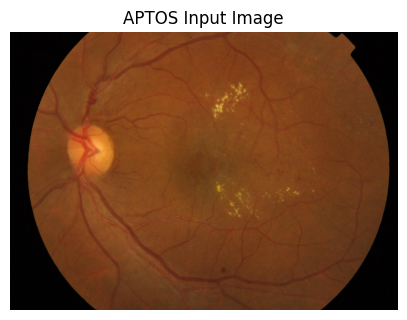

In [22]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Pick one validation image
image_name = sorted(os.listdir(VALID_DIR))[10]

image_path = os.path.join(
    VALID_DIR,
    image_name
)

print("Using image:", image_path)


# Load image
original = Image.open(image_path).convert("RGB")


# Apply same transform used for Swin
input_tensor = transform(original)


# Add batch dimension
input_batch = input_tensor.unsqueeze(0).to(device)


# Show image
plt.figure(figsize=(5,5))
plt.imshow(original)
plt.axis("off")
plt.title("APTOS Input Image")
plt.show()

In [23]:
import os
from PIL import Image
import torch

# Select image
image_name = sorted(os.listdir(VALID_DIR))[10]

image_path = os.path.join(
    VALID_DIR,
    image_name
)

print("Using:", image_path)

# Load
original = Image.open(image_path).convert("RGB")

# Transform
input_tensor = transform(original)

# Batch + device
input_batch = input_tensor.unsqueeze(0).to(device)

print("Input shape:", input_batch.shape)

Using: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images/1bb0ddfe753a.png
Input shape: torch.Size([1, 3, 224, 224])


In [24]:
swin_model.eval()

with torch.no_grad():

    output = swin_model(
        input_batch
    )


probabilities = torch.softmax(
    output,
    dim=1
)


prediction = torch.argmax(
    probabilities,
    dim=1
).item()


confidence = (
    probabilities[0][prediction].item()
    * 100
)


print("Prediction:", prediction)
print("Confidence:", round(confidence, 2), "%")

Prediction: 0
Confidence: 96.26 %


In [25]:
target_layers = [
    swin_model.layers[-1].blocks[-1].norm1
]

In [26]:
cam = GradCAM(
    model=swin_model,
    target_layers=target_layers
)


targets = [
    ClassifierOutputTarget(prediction)
]


grayscale_cam = cam(
    input_tensor=input_batch,
    targets=targets
)


grayscale_cam = grayscale_cam[0]

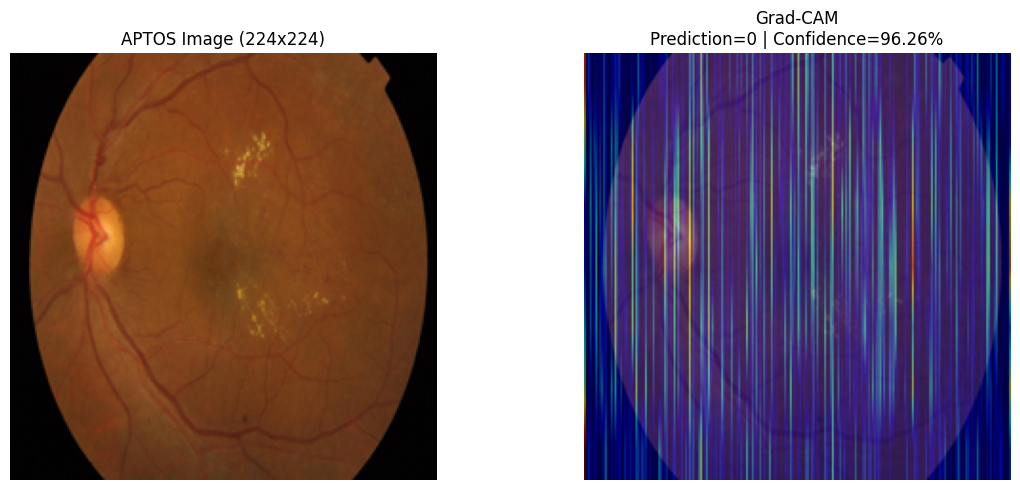

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# Resize original to model input size
cam_image = original.resize((224,224))


img_np = np.array(cam_image).astype(np.float32) / 255.0


visualization = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)


plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.imshow(cam_image)
plt.title("APTOS Image (224x224)")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title(
    f"Grad-CAM\nPrediction={prediction} | Confidence={confidence:.2f}%"
)
plt.axis("off")


plt.tight_layout()
plt.show()

In [32]:
cv2.imwrite(
    "swin_raae_gradcam.png",
    cv2.cvtColor(
        visualization,
        cv2.COLOR_RGB2BGR
    )
)

print("Saved!")

Saved!
